<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/gradient-collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Example


In [27]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

Original shape: (32, 32, 32, 3)
Rotated Crop shape: (32, 16, 16, 3)
Transformation shape: (32, 3)


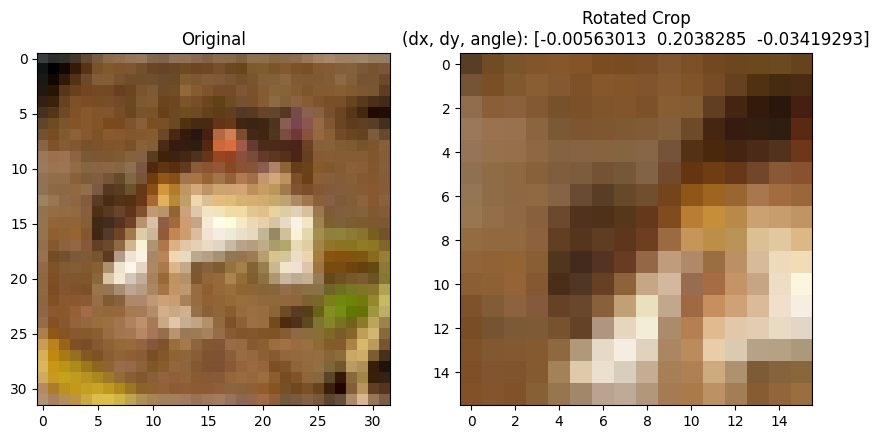

Time for 100 batches: 0.78 seconds


In [32]:
# pre-processing pipeline
def preprocess_image(image):
    # Original image as first input
    original_image = image

    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    #print(f"original_image: {original_image.shape}, {img_height=}, {img_width=}, {crop_size=}")

    # Random center offset (normal distribution around center)
    center_x = img_width / 2.0
    center_y = img_height / 2.0
    offset_x = tf.random.normal([], mean=0, stddev=img_width/8)
    offset_y = tf.random.normal([], mean=0, stddev=img_height/8)
    #offset_x, offset_y = tf.constant(5.0), tf.constant(0.0)  # FORCE value for debugging
    crop_center_x = center_x + offset_x
    crop_center_y = center_y + offset_y
    #print(f"center: ({center_x}, {center_y}), offset: ({offset_x}, {offset_y}), crop_centre: {crop_center_x.numpy(), crop_center_y.numpy()}")

    # Random rotation (normal distribution, mean 0, stddev 45 degrees)
    angle_deg = tf.random.normal([], mean=0.0, stddev=45.0/8)
    #angle_deg = -45.0  # FORCE value for debugging
    angle_rad = angle_deg * np.pi / 180.0
    #print(f"rotation: {angle_deg=}, {angle_rad=}")

    # Directly compute the homography matrix from translation and rotation
    cos_val = tf.cos(angle_rad)
    sin_val = tf.sin(angle_rad)
    tx = crop_center_x - center_x
    ty = crop_center_y - center_y

    h_matrix = tf.stack([
        [cos_val, -sin_val, tx],
        [sin_val, cos_val, ty],
        [0.0, 0.0, 1.0]
    ])

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    #print(f"{h_matrix=}")

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    # Ground-truth transformation: (dx, dy, angle_deg)
    dx = offset_x / img_width   # Normalized offset
    dy = offset_y / img_height  # Normalized offset
    da = angle_rad / np.pi  # Normalized angle
    transformation = tf.stack([dx, dy, da])

    return (original_image, rotated_crop), transformation

# Create the dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, rotated_crop), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", rotated_crop.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original[0])
    plt.subplot(1, 2, 2)
    plt.title(f"Rotated Crop\n(dx, dy, angle): {transform[0].numpy()}")
    plt.imshow(rotated_crop[0])
    plt.show()

# Optional: Time the pipeline
import time
start = time.time()
for _ in train_dataset.take(100):  # Process 100 batches
    pass
print(f"Time for 100 batches: {time.time() - start:.2f} seconds")